# Mexico Toy Sales and Inventory Analysis

本项目使用 Pandas 对玩具销售和库存数据进行清洗与分析，并为后续 Power BI 报表准备数据。

## 1. Data Loading and Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# 读取数据
sales = pd.read_csv("data/sales.csv")
products = pd.read_csv("data/products.csv")
stores = pd.read_csv("data/stores.csv")
inventory = pd.read_csv("data/inventory.csv")

In [3]:
# 查看数据规模
print("sales:", sales.shape)
print("products:", products.shape)
print("stores:", stores.shape)
print("inventory:", inventory.shape)

sales: (829262, 5)
products: (35, 5)
stores: (50, 5)
inventory: (1593, 3)


In [4]:
# 查看前 5 行
display(sales.head())
display(products.head())
display(stores.head())
display(inventory.head())

,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2017-01-01,24,4,1
1,2,2017-01-01,28,1,1
2,3,2017-01-01,6,8,1
3,4,2017-01-01,48,7,1
4,5,2017-01-01,44,18,1


,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,Action Figure,Toys,$9.99,$15.99
1,2,Animal Figures,Toys,$9.99,$12.99
2,3,Barrel O' Slime,Art & Crafts,$1.99,$3.99
3,4,Chutes & Ladders,Games,$9.99,$12.99
4,5,Classic Dominoes,Games,$7.99,$9.99


,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27
3,4,Maven Toys Saltillo 1,Saltillo,Downtown,2000-01-01
4,5,Maven Toys La Paz 1,La Paz,Downtown,2001-05-31


,Store_ID,Product_ID,Stock_On_Hand
0,1,1,27
1,1,2,0
2,1,3,32
3,1,4,6
4,1,5,0


In [5]:
# 查看字段类型
print("sales 数据类型：\n", sales.dtypes)
print("\nproducts 数据类型：\n", products.dtypes)
print("\nstores 数据类型：\n", stores.dtypes)
print("\ninventory 数据类型：\n", inventory.dtypes)

sales 数据类型：
 Sale_ID        int64
Date          object
Store_ID       int64
Product_ID     int64
Units          int64
dtype: object

products 数据类型：
 Product_ID           int64
Product_Name        object
Product_Category    object
Product_Cost        object
Product_Price       object
dtype: object

stores 数据类型：
 Store_ID            int64
Store_Name         object
Store_City         object
Store_Location     object
Store_Open_Date    object
dtype: object

inventory 数据类型：
 Store_ID         int64
Product_ID       int64
Stock_On_Hand    int64
dtype: object


## 2. Data Cleaning and Validation

In [6]:
# 清洗日期字段
sales["Date"] = pd.to_datetime(sales["Date"])
stores["Store_Open_Date"] = pd.to_datetime(stores["Store_Open_Date"])

In [7]:
# 清洗商品成本和价格
products["Product_Cost"] = (
    products["Product_Cost"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.strip()
    .astype(float)
)

products["Product_Price"] = (
    products["Product_Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.strip()
    .astype(float)
)

products[["Product_Cost", "Product_Price"]].dtypes

Product_Cost     float64
Product_Price    float64
dtype: object

In [8]:
# 检查缺失值
print("sales 缺失值：\n", sales.isnull().sum())
print("\nproducts 缺失值：\n", products.isnull().sum())
print("\nstores 缺失值：\n", stores.isnull().sum())
print("\ninventory 缺失值：\n", inventory.isnull().sum())

sales 缺失值：
 Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64

products 缺失值：
 Product_ID          0
Product_Name        0
Product_Category    0
Product_Cost        0
Product_Price       0
dtype: int64

stores 缺失值：
 Store_ID           0
Store_Name         0
Store_City         0
Store_Location     0
Store_Open_Date    0
dtype: int64

inventory 缺失值：
 Store_ID         0
Product_ID       0
Stock_On_Hand    0
dtype: int64


In [9]:
# 检查重复值
print("sales 完全重复行：", sales.duplicated().sum())
print("products 完全重复行：", products.duplicated().sum())
print("stores 完全重复行：", stores.duplicated().sum())
print("inventory 完全重复行：", inventory.duplicated().sum())

print("\nsales 的 Sale_ID 重复：", sales["Sale_ID"].duplicated().sum())
print("products 的 Product_ID 重复：", products["Product_ID"].duplicated().sum())
print("stores 的 Store_ID 重复：", stores["Store_ID"].duplicated().sum())
print(
    "inventory 的 Store_ID + Product_ID 重复：",
    inventory.duplicated(subset=["Store_ID", "Product_ID"]).sum()
)

sales 完全重复行： 0
products 完全重复行： 0
stores 完全重复行： 0
inventory 完全重复行： 0

sales 的 Sale_ID 重复： 0
products 的 Product_ID 重复： 0
stores 的 Store_ID 重复： 0
inventory 的 Store_ID + Product_ID 重复： 0


## 3. Sales Data Preparation

In [10]:
# 合并销售、商品和门店数据
sales_data = sales.merge(
    products,
    on="Product_ID",
    how="left",
    validate="many_to_one"
)

sales_data = sales_data.merge(
    stores,
    on="Store_ID",
    how="left",
    validate="many_to_one"
)

print("合并前行数：", len(sales))
print("合并后行数：", len(sales_data))
print("Product_Name 缺失：", sales_data["Product_Name"].isna().sum())
print("Store_Name 缺失：", sales_data["Store_Name"].isna().sum())

合并前行数： 829262
合并后行数： 829262
Product_Name 缺失： 0
Store_Name 缺失： 0


In [11]:
# 计算销售额、成本和毛利润
sales_data["Sales"] = sales_data["Units"] * sales_data["Product_Price"]
sales_data["Cost"] = sales_data["Units"] * sales_data["Product_Cost"]
sales_data["Profit"] = sales_data["Sales"] - sales_data["Cost"]

sales_data[
    ["Units", "Product_Price", "Product_Cost", "Sales", "Cost", "Profit"]
].head()

,Units,Product_Price,Product_Cost,Sales,Cost,Profit
0,1,12.99,9.99,12.99,9.99,3.0
1,1,15.99,9.99,15.99,9.99,6.0
2,1,6.99,3.99,6.99,3.99,3.0
3,1,15.99,11.99,15.99,11.99,4.0
4,1,39.99,34.99,39.99,34.99,5.0


## 4. Sales Performance Analysis

In [12]:
# 整体销售指标
total_units = sales_data["Units"].sum()
total_sales = sales_data["Sales"].sum()
total_cost = sales_data["Cost"].sum()
total_profit = sales_data["Profit"].sum()
gross_profit_margin = total_profit / total_sales * 100

print(f"Total Units: {total_units:,.0f}")
print(f"Total Sales: MXN {total_sales:,.2f}")
print(f"Total Cost: MXN {total_cost:,.2f}")
print(f"Gross Profit: MXN {total_profit:,.2f}")
print(f"Gross Profit Margin: {gross_profit_margin:.2f}%")

Total Units: 1,090,565
Total Sales: MXN 14,444,572.35
Total Cost: MXN 10,430,543.35
Gross Profit: MXN 4,014,029.00
Gross Profit Margin: 27.79%


In [13]:
# 商品类别分析
category_summary = (
    sales_data.groupby("Product_Category")
    .agg(
        Total_Units=("Units", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("Total_Sales", ascending=False)
    .reset_index(drop=True)
)

category_summary["Profit_Margin"] = (
    category_summary["Total_Profit"] / category_summary["Total_Sales"] * 100
).round(2)

category_summary

,Product_Category,Total_Units,Total_Sales,Total_Cost,Total_Profit,Profit_Margin
0,Toys,267200,5093241.00,4013714.00,1079527.0,21.20
1,Art & Crafts,325574,2705364.26,1952010.26,753354.0,27.85
2,Electronics,134075,2246771.25,1245334.25,1001437.0,44.57
3,Games,194673,2226836.27,1552843.27,673993.0,30.27
4,Sports & Outdoors,169043,2172359.57,1666641.57,505718.0,23.28


In [14]:
# 商品分析
product_summary = (
    sales_data.groupby(["Product_ID", "Product_Name", "Product_Category"])
    .agg(
        Total_Units=("Units", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

product_summary["Profit_Margin"] = (
    product_summary["Total_Profit"] / product_summary["Total_Sales"] * 100
).round(2)

product_summary.sort_values("Total_Sales", ascending=False).head(10).reset_index(drop=True)

,Product_ID,Product_Name,Product_Category,Total_Units,Total_Sales,Total_Cost,Total_Profit,Profit_Margin
0,18,Lego Bricks,Toys,59737,2388882.63,2090197.63,298685.0,12.50
1,6,Colorbuds,Electronics,104368,1564476.32,729532.32,834944.0,53.37
2,19,Magic Sand,Art & Crafts,60598,968962.02,847766.02,121196.0,12.51
3,1,Action Figure,Toys,57958,926748.42,579000.42,347748.0,37.52
4,30,Rubik's Cube,Games,45672,912983.28,821639.28,91344.0,10.01
5,8,Deck Of Cards,Games,84034,587397.66,335295.66,252102.0,42.92
6,31,Splash Balls,Sports & Outdoors,60248,541629.52,481381.52,60248.0,11.12
7,24,Nerf Gun,Sports & Outdoors,26543,530594.57,397879.57,132715.0,25.01
8,2,Animal Figures,Toys,39089,507766.11,390499.11,117267.0,23.09
9,7,Dart Gun,Sports & Outdoors,31588,505092.12,378740.12,126352.0,25.02


In [15]:
# 门店分析
store_summary = (
    sales_data.groupby(["Store_ID", "Store_Name", "Store_City", "Store_Location"])
    .agg(
        Total_Units=("Units", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

store_summary["Profit_Margin"] = (
    store_summary["Total_Profit"] / store_summary["Total_Sales"] * 100
).round(2)

store_summary.sort_values("Total_Sales", ascending=False).head(10).reset_index(drop=True)

,Store_ID,Store_Name,Store_City,Store_Location,Total_Units,Total_Sales,Total_Cost,Total_Profit,Profit_Margin
0,31,Maven Toys Ciudad de Mexico 2,Cuidad de Mexico,Airport,42757,554553.43,384697.43,169856.0,30.63
1,30,Maven Toys Guadalajara 3,Guadalajara,Airport,31609,449354.91,327783.91,121571.0,27.05
2,9,Maven Toys Ciudad de Mexico 1,Cuidad de Mexico,Downtown,33479,433556.21,322260.21,111296.0,25.67
3,17,Maven Toys Toluca 1,Toluca,Downtown,32668,411157.32,306545.32,104612.0,25.44
4,7,Maven Toys Monterrey 2,Monterrey,Downtown,28318,372998.82,266215.82,106783.0,28.63
5,46,Maven Toys Guadalajara 4,Guadalajara,Downtown,24136,348466.64,246288.64,102178.0,29.32
6,42,Maven Toys Hermosillo 3,Hermosillo,Commercial,23236,344846.64,246021.64,98825.0,28.66
7,39,Maven Toys Xalapa 2,Xalapa,Downtown,25296,344307.04,255670.04,88637.0,25.74
8,37,Maven Toys Ciudad de Mexico 3,Cuidad de Mexico,Residential,26634,337424.66,243403.66,94021.0,27.86
9,4,Maven Toys Saltillo 1,Saltillo,Downtown,24010,330408.90,236156.90,94252.0,28.53


In [16]:
# 月度趋势分析
monthly_summary = (
    sales_data.groupby(pd.Grouper(key="Date", freq="MS"))
    .agg(
        Total_Units=("Units", "sum"),
        Total_Sales=("Sales", "sum"),
        Total_Cost=("Cost", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .rename(columns={"Date": "Month"})
)

monthly_summary["Profit_Margin"] = (
    monthly_summary["Total_Profit"] / monthly_summary["Total_Sales"] * 100
).round(2)

monthly_summary

,Month,Total_Units,Total_Sales,Total_Cost,Total_Profit,Profit_Margin
0,2017-01-01,38009,542554.91,375428.91,167126.0,30.80
1,2017-02-01,36935,541351.65,379490.65,161861.0,29.90
2,2017-03-01,39981,589485.19,415493.19,173992.0,29.52
3,2017-04-01,47102,681072.98,490973.98,190099.0,27.91
4,2017-05-01,46910,672369.90,485475.90,186894.0,27.80
5,2017-06-01,47178,661980.22,472165.22,189815.0,28.67
6,2017-07-01,46177,556034.23,379112.23,176922.0,31.82
7,2017-08-01,39927,489422.73,330491.73,158931.0,32.47
8,2017-09-01,42196,585844.04,419447.04,166397.0,28.40
9,2017-10-01,47861,623874.39,445075.39,178799.0,28.66


## 5. Inventory Analysis

In [17]:
# 合并库存、商品和门店数据
inventory_data = inventory.merge(
    products,
    on="Product_ID",
    how="left",
    validate="many_to_one"
)

inventory_data = inventory_data.merge(
    stores,
    on="Store_ID",
    how="left",
    validate="many_to_one"
)

In [18]:
# 计算库存价值和缺货标记
inventory_data["Inventory_Cost_Value"] = (
    inventory_data["Stock_On_Hand"] * inventory_data["Product_Cost"]
)
inventory_data["Inventory_Retail_Value"] = (
    inventory_data["Stock_On_Hand"] * inventory_data["Product_Price"]
)
inventory_data["Out_of_Stock_Flag"] = (
    inventory_data["Stock_On_Hand"] == 0
).astype(int)

inventory_data.head()

,Store_ID,Product_ID,Stock_On_Hand,Product_Name,Product_Category,Product_Cost,Product_Price,Store_Name,Store_City,Store_Location,Store_Open_Date,Inventory_Cost_Value,Inventory_Retail_Value,Out_of_Stock_Flag
0,1,1,27,Action Figure,Toys,9.99,15.99,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18,269.73,431.73,0
1,1,2,0,Animal Figures,Toys,9.99,12.99,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18,0.00,0.00,1
2,1,3,32,Barrel O' Slime,Art & Crafts,1.99,3.99,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18,63.68,127.68,0
3,1,4,6,Chutes & Ladders,Games,9.99,12.99,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18,59.94,77.94,0
4,1,5,0,Classic Dominoes,Games,7.99,9.99,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18,0.00,0.00,1


In [19]:
# 汇总最近 90 天销量
end_date = sales_data["Date"].max()
start_date = end_date - pd.Timedelta(days=89)

recent_sales_summary = (
    sales_data[sales_data["Date"].between(start_date, end_date)]
    .groupby(["Store_ID", "Product_ID"])
    .agg(Recent_90D_Units=("Units", "sum"))
    .reset_index()
)

In [20]:
# 计算库存可支撑天数
inventory_analysis = inventory_data.merge(
    recent_sales_summary,
    on=["Store_ID", "Product_ID"],
    how="left",
    validate="one_to_one"
)

inventory_analysis["Recent_90D_Units"] = (
    inventory_analysis["Recent_90D_Units"].fillna(0).astype(int)
)

inventory_analysis["Days_of_Inventory"] = (
    inventory_analysis["Stock_On_Hand"]
    / (inventory_analysis["Recent_90D_Units"] / 90).where(
        inventory_analysis["Recent_90D_Units"] > 0
    )
).round(1)

inventory_analysis["Avg_Daily_Units"] = (
    inventory_analysis["Recent_90D_Units"] / 90
).round(2)

inventory_analysis[
    [
        "Store_ID", "Product_ID", "Stock_On_Hand",
        "Inventory_Cost_Value", "Inventory_Retail_Value",
        "Out_of_Stock_Flag", "Recent_90D_Units",
        "Avg_Daily_Units", "Days_of_Inventory"
    ]
].head()

,Store_ID,Product_ID,Stock_On_Hand,Inventory_Cost_Value,Inventory_Retail_Value,Out_of_Stock_Flag,Recent_90D_Units,Avg_Daily_Units,Days_of_Inventory
0,1,1,27,269.73,431.73,0,107,1.19,22.7
1,1,2,0,0.00,0.00,1,123,1.37,0.0
2,1,3,32,63.68,127.68,0,247,2.74,11.7
3,1,4,6,59.94,77.94,0,27,0.30,20.0
4,1,5,0,0.00,0.00,1,25,0.28,0.0


## 6. Data Visualization

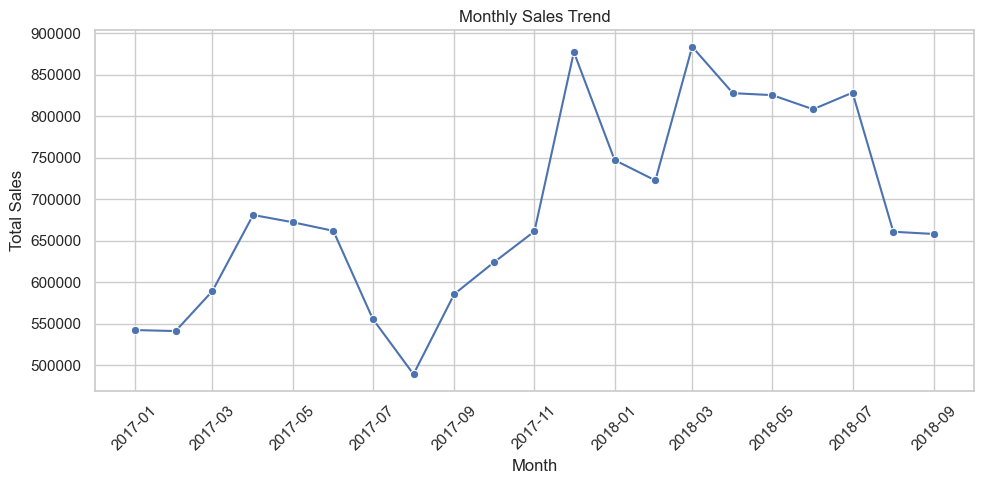

In [21]:
# 月度销售额趋势
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_summary, x="Month", y="Total_Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

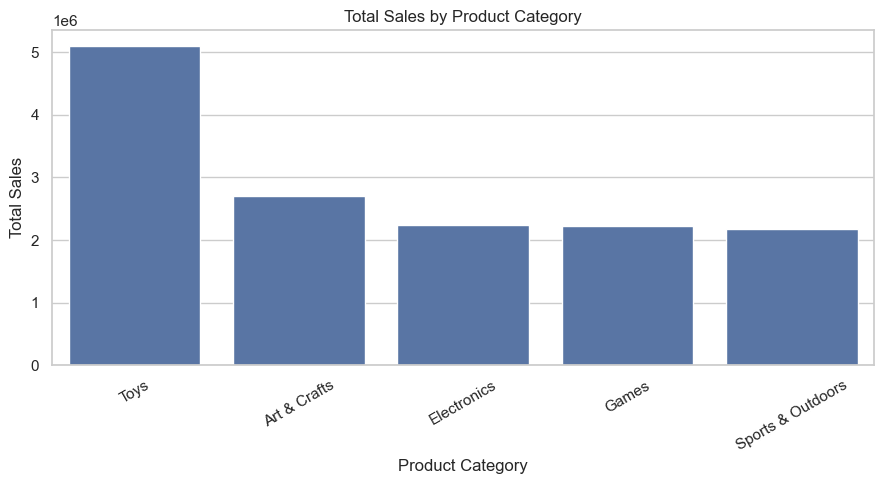

In [22]:
# 各商品类别销售额
plt.figure(figsize=(9, 5))
sns.barplot(data=category_summary, x="Product_Category", y="Total_Sales")
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

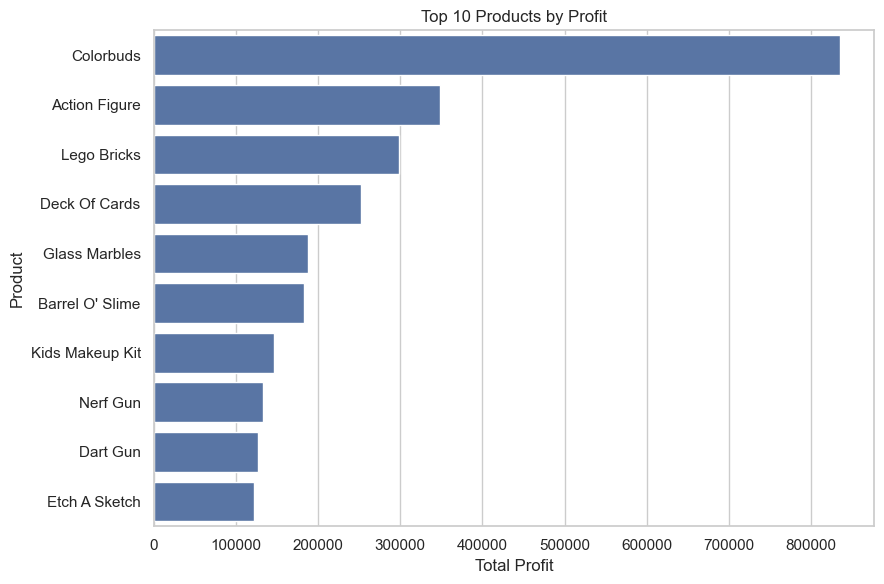

In [23]:
# 毛利润最高的前 10 个商品
plt.figure(figsize=(9, 6))
sns.barplot(
    data=product_summary.nlargest(10, "Total_Profit"),
    x="Total_Profit",
    y="Product_Name"
)
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 7. Power BI Data Export

In [24]:
import os

# 创建输出文件夹
os.makedirs("output", exist_ok=True)

# 准备Power BI使用的数据
sales_fact = sales_data[
    ["Sale_ID", "Date", "Store_ID", "Product_ID", "Units", "Sales", "Cost", "Profit"]
]

inventory_fact = inventory_analysis[
    [
        "Store_ID", "Product_ID", "Stock_On_Hand",
        "Inventory_Cost_Value", "Inventory_Retail_Value",
        "Out_of_Stock_Flag", "Recent_90D_Units",
        "Avg_Daily_Units", "Days_of_Inventory"
    ]
]

# 导出数据
sales_fact.to_csv("output/sales_fact.csv", index=False)
products.to_csv("output/products.csv", index=False)
stores.to_csv("output/stores.csv", index=False)
inventory_fact.to_csv("output/inventory_fact.csv", index=False)


## 8. Key Findings

- 2017-01-01 至 2018-09-30 共售出 **1,090,565** 件商品，销售额为 **MXN 14,444,572.35**，毛利润为 **MXN 4,014,029.00**，毛利率为 **27.79%**。
- **Toys** 是销售额最高的商品类别，销售额为 **MXN 5,093,241.00**。
- **Colorbuds** 的毛利润最高，为 **MXN 834,944.00**。
- **2018 年 3 月**的月度销售额最高，为 **MXN 883,515.64**。